In [1]:
#Support Vector Regression (SVR)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
#Load dataset
df = pd.read_csv('Oil_Well.csv')
x = df.iloc[:, [5, 8]].values
y = df.iloc[:, 1].values.reshape(-1, 1)

In [3]:
#Split dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [4]:
#Feature Scaling
sc_x = StandardScaler()
sc_y = StandardScaler()
x_train_sc = sc_x.fit_transform(x_train)
x_test_sc = sc_x.transform(x_test)
y_train_sc = sc_y.fit_transform(y_train).ravel()

In [5]:
print(y_train_sc)

[ 1.48739302  0.8678765  -0.16465103 ... -0.16465103 -0.47440929
  0.24835998]


In [6]:
#Train SVR model
Powei = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
Powei.fit(x_train_sc, y_train_sc)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [7]:
#Predicting the Test set results and inverse transform the predictions
y_pred_sc = Powei.predict(x_test_sc)
y_pred = sc_y.inverse_transform(y_pred_sc.reshape(-1, 1)).ravel()
y_test = y_test.ravel()

In [8]:
#Evaluate
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rsme = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


In [9]:
print(f'Kernel : rbf')
print(f'C :100, Gamma: 0.1, Epsilon: 0.1')
print(f'mae: {mae:.4f}')
print(f'mse: {mse:.4f}')
print(f'rmse: {rsme:.4f}')
print(f'r2: {r2:.4f}')

Kernel : rbf
C :100, Gamma: 0.1, Epsilon: 0.1
mae: 1.2389
mse: 3.0932
rmse: 1.7587
r2: 0.9671


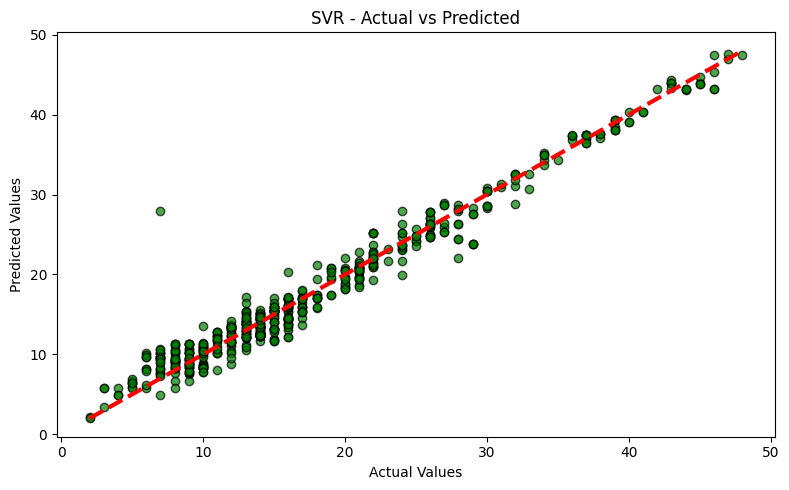

In [10]:
#Plot Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='green', edgecolor='black', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--",  lw=3)  # Line for perfect predictions
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('SVR - Actual vs Predicted')
plt.tight_layout()
plt.savefig('SVR_Actual_vs_Predicted.png', dpi=150)
plt.show()